# Notebook 02 — Descriptive Statistics
Produces all tables and figures for the Results Section 4.1:
- Table 1: Sample demographics  
- Table 2: Treatment distribution  
- Table 3: Green extraction rate by condition  
- Figure 1: Green extraction rate by round & condition  
- Figure 2: Green extraction rate by ideology group  


In [1]:
# ── Cell 1: Load clean data ──────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 150})
os.makedirs('outputs', exist_ok=True)

df_mt = pd.read_csv('data/mturk_clean.csv')
df_pr = pd.read_csv('data/prolific_clean.csv')
datasets = {'mturk': df_mt, 'prolific': df_pr}
PLATFORMS = {'mturk': 'Study 1 (MTurk)', 'prolific': 'Study 2 (Prolific)'}


In [2]:
# ── Cell 2: Table 1 — Sample demographics ────────────────────
# Aggregate to participant level (one row per person) to avoid
# inflating counts across the 10 decision rounds.

def demographics_table(df, label):
    p = df.drop_duplicates('participantcode')
    n = len(p)
    print(f"\n{'='*55}")
    print(f"  {label}  (N = {n:,})")
    print(f"{'='*55}")
    print(f"Age:  mean={p['age'].mean():.1f}, SD={p['age'].std():.1f}, "
          f"range={int(p['age'].min())}–{int(p['age'].max())}")
    print("\nGender:")
    print(p['gender'].value_counts().rename(
        {1:'Male', 2:'Female', 3:'Other'}))
    print("\nEducation (1=<HS … 7=Graduate):")
    print(p['education'].value_counts().sort_index())
    print("\nIdeology group:")
    print(p['ideology_group'].value_counts())
    if 'dem_rep' in p.columns:
        print("\ndem_rep (election_2024):")
        print(p['dem_rep'].value_counts(dropna=False)
              .rename({1.0:'Democrat', 0.0:'Republican'}))
    if 'dem_rep_party_id' in p.columns:
        print("\ndem_rep_party_id (political_orientation 1–7):")
        print(p['dem_rep_party_id'].value_counts(dropna=False))
        print(f"  (NaN = {p['dem_rep_party_id'].isna().sum()})")

for name, df in datasets.items():
    demographics_table(df, PLATFORMS[name])


  Study 1 (MTurk)  (N = 1,167)
Age:  mean=40.1, SD=11.8, range=18–83

Gender:
gender
Male      610
Female    534
Other       3
Name: count, dtype: int64

Education (1=<HS … 7=Graduate):
education
1.0    101
2.0    187
3.0    111
4.0    519
5.0    229
Name: count, dtype: int64

Ideology group:
ideology_group
Liberal         633
Conservative    325
Moderate        205
Name: count, dtype: int64

  Study 2 (Prolific)  (N = 1,093)
Age:  mean=36.2, SD=13.0, range=18–84

Gender:
gender
Female    541
Male      525
Other      23
Name: count, dtype: int64

Education (1=<HS … 7=Graduate):
education
1.0    139
2.0    229
3.0    101
4.0    423
5.0    197
Name: count, dtype: int64

Ideology group:
ideology_group
Liberal         682
Conservative    211
Moderate        196
Name: count, dtype: int64

dem_rep (election_2024):
dem_rep
Democrat      794
Republican    295
NaN             4
Name: count, dtype: int64

dem_rep_party_id (political_orientation 1–7):
dem_rep_party_id
1.0    675
0.0    229
NaN  

In [3]:
# ── Cell 3: Table 2 — Treatment distribution ─────────────────
# One row per participant; conditions are constant within person.

print("Treatment distribution (participant level)\n")
for name, df in datasets.items():
    p = df.drop_duplicates('participantcode')
    print(f"{PLATFORMS[name]}:")
    print(p['cpr1groupgrp_treat_num'].value_counts())
    print()


Treatment distribution (participant level)

Study 1 (MTurk):
cpr1groupgrp_treat_num
NIT&NGI    308
IT&GI      307
GI         286
IT         266
Name: count, dtype: int64

Study 2 (Prolific):
cpr1groupgrp_treat_num
GI         319
IT&GI      282
NIT&NGI    251
IT         241
Name: count, dtype: int64



In [4]:
# ── Cell 4: Table 3 — Green extraction rate by condition ──────
# extraction_2 = 1 if participant chose the green option (binary DV).
# Mean = Pr(green choice) across all rounds and participants.

print("Green extraction rate (Pr[extraction_2=1]) by condition\n")
for name, df in datasets.items():
    rates = (df.groupby('cpr1groupgrp_treat_num')['extraction_2']
               .agg(Mean='mean', SD='std', N='count')
               .round(3))
    print(f"{PLATFORMS[name]}:")
    print(rates)
    print()


Green extraction rate (Pr[extraction_2=1]) by condition

Study 1 (MTurk):
                         Mean     SD     N
cpr1groupgrp_treat_num                    
GI                      0.292  0.455  2791
IT                      0.271  0.444  2605
IT&GI                   0.343  0.475  2962
NIT&NGI                 0.161  0.367  3031

Study 2 (Prolific):
                         Mean     SD     N
cpr1groupgrp_treat_num                    
GI                      0.323  0.468  3110
IT                      0.311  0.463  2389
IT&GI                   0.369  0.483  2762
NIT&NGI                 0.208  0.406  2490



In [5]:
# ── Cell 5: Table 4 — Moderator descriptives ─────────────────
# Participant-level means (not inflated by round repetition).

print("Moderator descriptive statistics (participant level)\n")
MODS_LABELS = {
    'liberal':              'Ideology (1=lib–7=con)',
    'legacy_concern_comp':  'Legacy concern composite',
    'env_concern_comp':     'Environmental concern composite',
    'environment_worry':    'Climate worry (standalone)',
    'environment_responsib':'Personal responsibility (standalone)',
    'environment_natural_p':'Anthropogenic belief (standalone)',
}
for name, df in datasets.items():
    p = df.drop_duplicates('participantcode')
    rows = []
    for col, lbl in MODS_LABELS.items():
        if col in p.columns:
            rows.append({'Variable': lbl,
                         'Mean':  round(p[col].mean(), 3),
                         'SD':    round(p[col].std(),  3),
                         'Min':   round(p[col].min(),  1),
                         'Max':   round(p[col].max(),  1),
                         'N':     int(p[col].notna().sum())})
    print(f"{PLATFORMS[name]}:")
    print(pd.DataFrame(rows).to_string(index=False))
    print()


Moderator descriptive statistics (participant level)

Study 1 (MTurk):
                            Variable  Mean    SD  Min  Max    N
              Ideology (1=lib–7=con) 3.477 1.814  1.0  7.0 1163
          Climate worry (standalone) 3.452 1.146  1.0  5.0 1163
Personal responsibility (standalone) 7.118 2.783  1.0 11.0 1163
   Anthropogenic belief (standalone) 3.611 1.043  1.0  6.0 1163

Study 2 (Prolific):
                            Variable  Mean    SD  Min  Max    N
              Ideology (1=lib–7=con) 3.008 1.636  1.0  7.0 1089
            Legacy concern composite 3.047 0.902  1.0  5.0 1089
     Environmental concern composite 3.532 0.645  1.0  5.0 1089
          Climate worry (standalone) 3.601 1.114  1.0  5.0 1089
Personal responsibility (standalone) 6.637 2.684  1.0 11.0 1089
   Anthropogenic belief (standalone) 3.855 0.842  1.0  6.0 1089



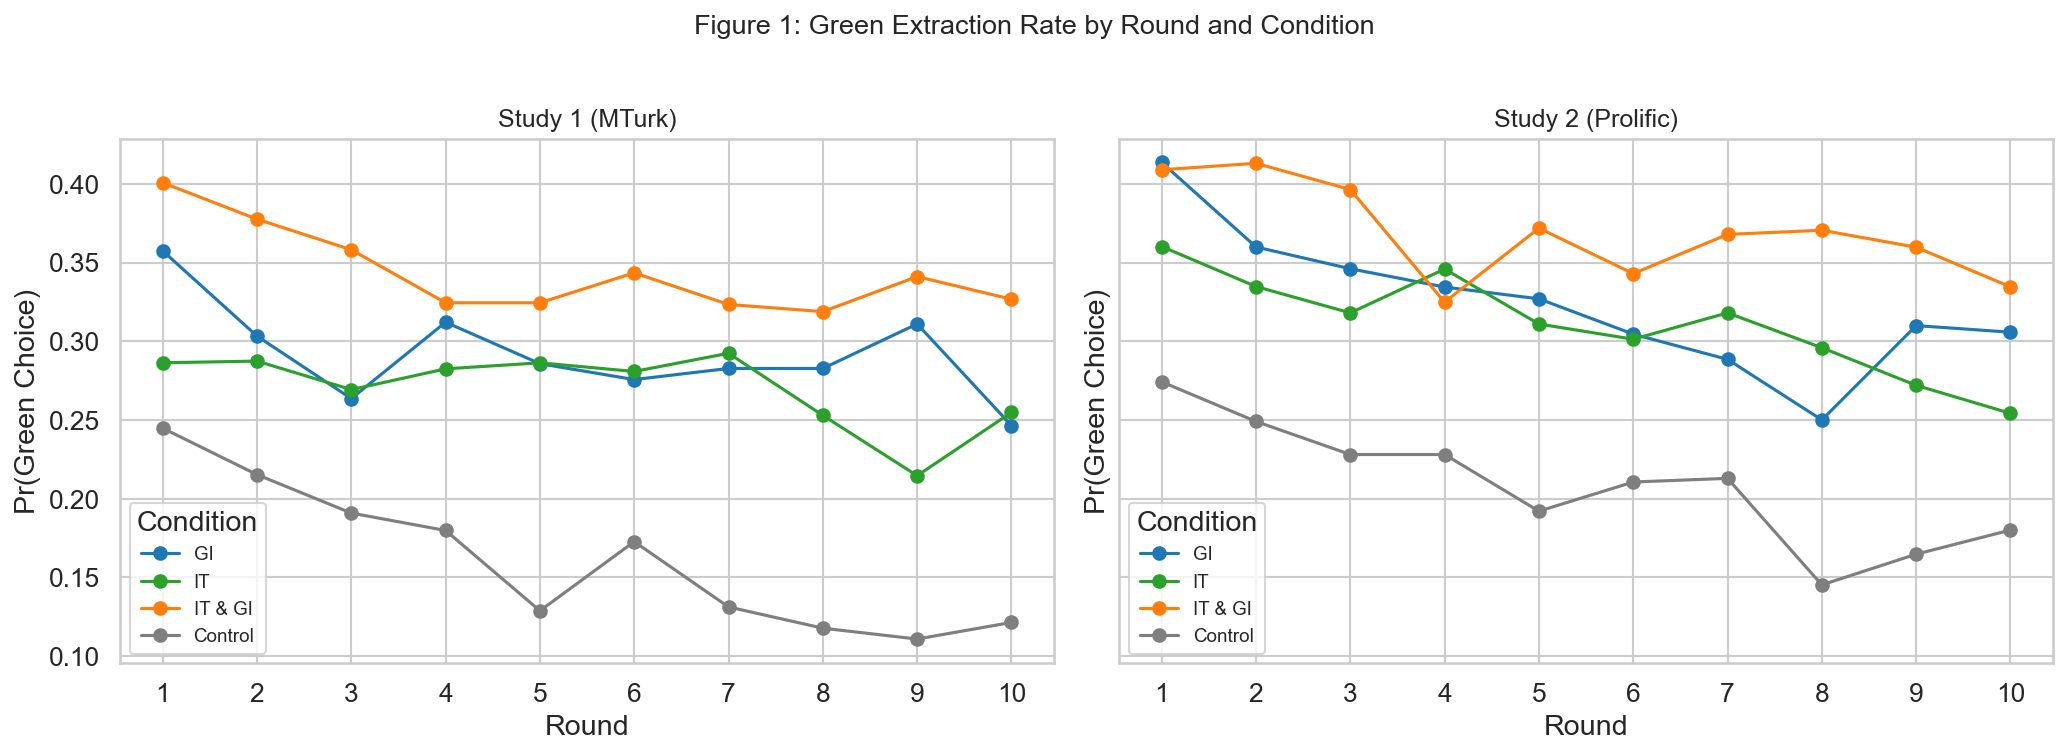

Saved: outputs/fig1_extraction_by_round.png


In [6]:
# ── Cell 6: Figure 1 — Extraction rate by round & condition ──
# Replicates Figure 1 of Testori & Lo Iacono (2026).

COND_LABELS = {
    'IT&GI':   'IT & GI',
    'IT&NGI':  'IT only',
    'NIT&GI':  'GI only',
    'NIT&NGI': 'Control'
}
PALETTE = ['#1f77b4', '#2ca02c', '#ff7f0e', '#7f7f7f']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    rd = (df.groupby(['round', 'cpr1groupgrp_treat_num'])
            ['extraction_2'].mean().reset_index())
    for i, (cond, grp) in enumerate(rd.groupby('cpr1groupgrp_treat_num')):
        ax.plot(grp['round'], grp['extraction_2'],
                marker='o', label=COND_LABELS.get(cond, cond),
                color=PALETTE[i % len(PALETTE)])
    ax.set_title(PLATFORMS[name], fontsize=12)
    ax.set_xlabel('Round')
    ax.set_ylabel('Pr(Green Choice)')
    ax.set_xticks(range(1, 11))
    ax.legend(title='Condition', fontsize=9)

plt.suptitle('Figure 1: Green Extraction Rate by Round and Condition',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig1_extraction_by_round.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig1_extraction_by_round.png")


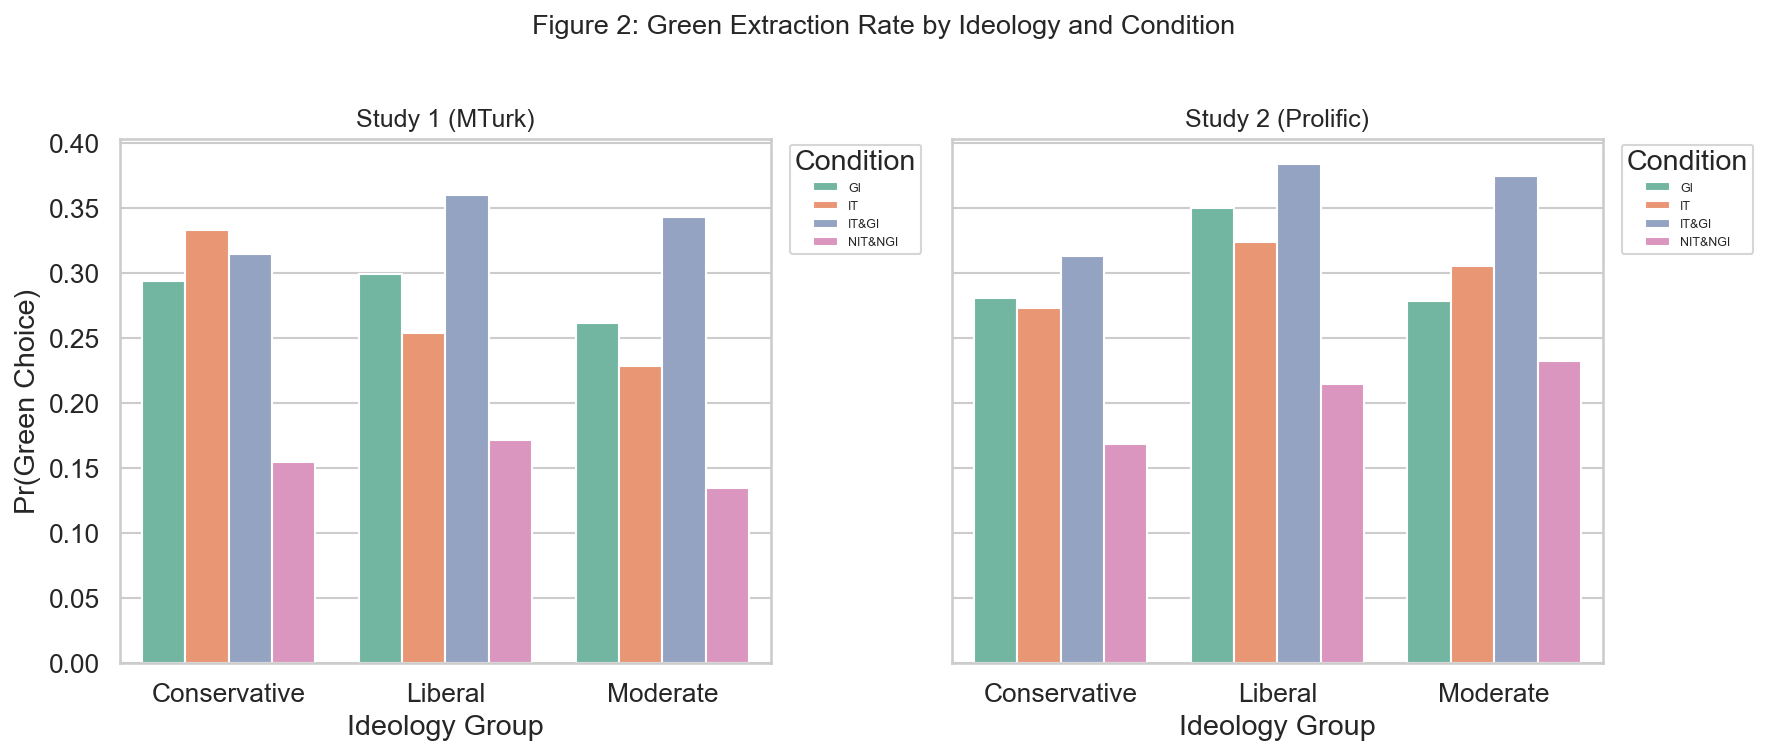

Saved: outputs/fig2_ideology_extraction.png


In [7]:
# ── Cell 7: Figure 2 — Extraction rate by ideology group ──────
# Descriptive precursor to H1; shows liberal–conservative gap
# separately for each treatment condition.

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    df_valid = df.dropna(subset=['ideology_group'])
    ideo = (df_valid.groupby(['ideology_group', 'cpr1groupgrp_treat_num'],
                              observed=True)
                    ['extraction_2'].mean().reset_index())
    sns.barplot(data=ideo, x='ideology_group', y='extraction_2',
                hue='cpr1groupgrp_treat_num', ax=ax, palette='Set2')
    ax.set_title(PLATFORMS[name], fontsize=12)
    ax.set_xlabel('Ideology Group')
    ax.set_ylabel('Pr(Green Choice)')
    ax.legend(title='Condition', fontsize=6, bbox_to_anchor=(1.02, 1))

plt.suptitle('Figure 2: Green Extraction Rate by Ideology and Condition',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig2_ideology_extraction.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig2_ideology_extraction.png")
